# ResNet18 Cloud Filter — All NASA GLOBE Classes

Runs the trained multi-head ResNet18 (head2) over every cloud-type folder in the NASA GLOBE dataset except `ClSk` (Clear Sky is already the negative class head2 was trained on). Results are collected into a single CSV for downstream filtering.

In [7]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as T
from torchvision.models import ResNet18_Weights
from pathlib import Path
import numpy as np

class MultiHeadResNet18(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(base.children())[:-1])
        self.head1 = base.fc
        self.head2 = nn.Linear(512, num_classes)
        for param in self.backbone.parameters():
            param.requires_grad = False
        for param in self.head1.parameters():
            param.requires_grad = False

    def forward(self, x):
        features = self.backbone(x).flatten(1)
        return self.head1(features), self.head2(features)

SAVE_PATH = Path("../models/multihead_resnet18_cloud_sky.pth")
checkpoint = torch.load(SAVE_PATH, map_location="cpu", weights_only=False)
classes = checkpoint["classes"]   # ['clear_sky', 'cloud']
cloud_idx = classes.index("cloud")

imagenet_classes = ResNet18_Weights.IMAGENET1K_V1.meta["categories"]

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = MultiHeadResNet18(num_classes=len(classes))
model.load_state_dict(checkpoint["model_state_dict"])
model.eval().to(device)

print(f"Model loaded. Classes: {classes}, device: {device}")

Model loaded. Classes: ['clear_sky', 'cloud'], device: mps


In [8]:
IMAGES_ROOT = Path("../resources/cloud-images/NASA_GLOBE_CD/downloaded_images")
SKIP_FOLDERS = {"ClSk"}
CONF_THRESHOLD = 0.9
BATCH_SIZE = 64

folders = sorted(
    p for p in IMAGES_ROOT.iterdir()
    if p.is_dir() and p.name not in SKIP_FOLDERS
)

print(f"Folders to process ({len(folders)}):")
for f in folders:
    n = len(list(f.glob("*.jpg"))) + len(list(f.glob("*.png")))
    print(f"  {f.name:6s}  {n:,} images")

Folders to process (11):
  Ac      35,627 images
  As      33,993 images
  Cb      9,453 images
  Cc      22,945 images
  Ci      77,068 images
  Cs      37,598 images
  Ct      200 images
  Cu      141,866 images
  Ns      25,256 images
  Sc      54,804 images
  St      28,810 images


In [9]:
import cv2
from tqdm.auto import tqdm
from torch.nn.functional import softmax

preprocess = T.Compose([
    T.ToPILImage(),
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

records = []

for folder in folders:
    image_paths = sorted(folder.glob("*.jpg")) + sorted(folder.glob("*.png"))
    print(f"\n{folder.name}: {len(image_paths):,} images")

    with torch.no_grad():
        for start in tqdm(range(0, len(image_paths), BATCH_SIZE)):
            batch_paths = image_paths[start:start + BATCH_SIZE]
            tensors, valid_paths = [], []
            for p in batch_paths:
                img = cv2.imread(str(p))
                if img is None:
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                tensors.append(preprocess(img))
                valid_paths.append(p)

            if not tensors:
                continue

            batch = torch.stack(tensors).to(device)
            out1, out2 = model(batch)
            probs2 = softmax(out2, dim=1).cpu().numpy()
            probs1 = softmax(out1, dim=1).cpu().numpy()

            for p, prob2, prob1 in zip(valid_paths, probs2, probs1):
                top1_idx = int(np.argmax(prob1))
                records.append({
                    "folder":      folder.name,
                    "filename":    p.name,
                    "head2_pred":  classes[int(np.argmax(prob2))],
                    "head2_conf":  float(prob2[cloud_idx]),
                    "head1_pred":  imagenet_classes[top1_idx],
                    "head1_conf":  float(prob1[top1_idx]),
                })

print(f"\nDone. Total records: {len(records):,}")


Ac: 35,627 images


100%|██████████| 557/557 [10:11<00:00,  1.10s/it]



As: 33,993 images


 65%|██████▍   | 344/532 [06:27<02:08,  1.47it/s]Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
Invalid SOS parameters for sequential JPEG
100%|██████████| 532/532 [08:52<00:00,  1.00s/it]



Cb: 9,453 images


...


Sc: 54,804 images


100%|██████████| 857/857 [13:24<00:00,  1.07it/s]



St: 28,810 images


100%|██████████| 451/451 [07:29<00:00,  1.00it/s]


Done. Total records: 467,620


In [10]:
import pandas as pd

results_df = pd.DataFrame(records)

summary = (
    results_df.groupby("folder")
    .apply(lambda g: pd.Series({
        "total":      len(g),
        "cloud":      (g["head2_pred"] == "cloud").sum(),
        "not_cloud":  (g["head2_pred"] == "clear_sky").sum(),
        "keep":       (g["head2_conf"] >= CONF_THRESHOLD).sum(),
        "keep_pct":   round(100 * (g["head2_conf"] >= CONF_THRESHOLD).sum() / len(g), 1),
    }), include_groups=False)
    .astype({"total": int, "cloud": int, "not_cloud": int, "keep": int})
)

print(summary.to_string())

         total   cloud  not_cloud   keep  keep_pct
folder                                            
Ac       35627   25679       9948  20430      57.3
As       33993   28316       5677  20363      59.9
Cb        9453    8067       1386   6720      71.1
Cc       22945   14785       8160  10163      44.3
Ci       77068   36364      40704  20494      26.6
Cs       37598   24413      13185  15692      41.7
Ct         200      69        131     28      14.0
Cu      141866  101351      40515  81991      57.8
Ns       25256   22370       2886  16631      65.8
Sc       54804   49853       4951  41942      76.5
St       28810   23076       5734  15734      54.6


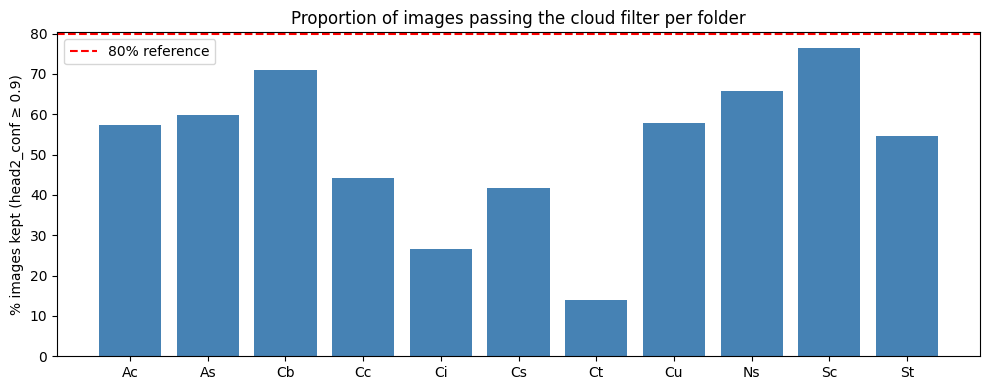

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(summary.index, summary["keep_pct"], color="steelblue")
ax.axhline(80, color="red", linestyle="--", label="80% reference")
ax.set_ylabel(f"% images kept (head2_conf ≥ {CONF_THRESHOLD})")
ax.set_title("Proportion of images passing the cloud filter per folder")
ax.legend()
plt.tight_layout()
plt.show()

In [12]:
EXPORT_PATH = Path("../resources/cloud-images/NASA_GLOBE_CD/cloud_filter_results.csv")
results_df.to_csv(EXPORT_PATH, index=False)
print(f"Exported {len(results_df):,} rows to {EXPORT_PATH}")
print(f"Clean images (head2_conf ≥ {CONF_THRESHOLD}): {(results_df['head2_conf'] >= CONF_THRESHOLD).sum():,}")

Exported 467,620 rows to ../resources/cloud-images/NASA_GLOBE_CD/cloud_filter_results.csv
Clean images (head2_conf ≥ 0.9): 250,188
